In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные

In [2]:
# Загружаем только необходимые колонки
df = pd.read_excel('data_orphans_127_v20241218.xlsx', 
                    usecols=['year', 'region', 'indicator_category', 'dimension', 
                            'main_level', 'indicator', 'indicator_value'])

# Быстро проверим размер
print(df.shape)
print(df.head(2))

(864205, 7)
   year             region                                 indicator_category  \
0  2014  Республика Адыгея  1. Учет и устройство детей, оставшихся без поп...   
1  2014  Республика Адыгея  1. Учет и устройство детей, оставшихся без поп...   

  dimension                                         main_level  \
0     всего  детей выявлено и учтено, всего, на конец отчет...   
1     всего  детей выявлено и учтено, всего, на конец отчет...   

                                           indicator  indicator_value  
0  детей, оставшихся неустроенными к началу отчет...                1  
1       детей, выявленных и учтенных за отчетный год              172  


In [3]:
print(df['main_level'].unique())

<StringArray>
[                                                                                                                                                                                                                                   'детей выявлено и учтено, всего, на конец отчетного года',
                                                                                                                                                                                                                                               'детей, выявленных и учтенных за отчетный год',
                                                                                                                                                                                                                                                                                       'main',
                                                                                                                             

# Дети, устроенные в семьи за год

In [ ]:
df_3 = df[df['indicator_category'] == '3. Устройство детей в семьи']
print("Уникальные dimension:", df_3['dimension'].unique())
print("Уникальные main_level:", df_3['main_level'].unique())
print("Уникальные indicator:", df_3['indicator'].unique())

Уникальные dimension: <StringArray>
[                  'устроено в семьи, всего',
          'устроено в семьи детей до 1 года',
 'устроено в семьи детей от 1 года до 3 лет',
      'устроено в семьи детей от 3 до 7 лет',
  'устроено в семьи детей от 7 лет и старше',
          'устроено в семьи детей-инвалидов']
Length: 6, dtype: str
Уникальные main_level: <StringArray>
[                                                                                            'main',
 'численность детей, переданных на безвозмездную форму опеки (попечительства) на конец года, всего',
    'численность детей, переданных на возмездную форму опеки (попечительства) на конец года, всего',
                                              'численность усыновленных детей на конец года, всего',
                'численность усыновленных детей на конец года, иностранными гражданами, по странам']
Length: 5, dtype: str
Уникальные indicator: <StringArray>
[                                                                 

In [15]:
df_vsp = df[df['indicator'].str.contains('устроено в семьи, всего', na=False)][['indicator', 'indicator_category', 'dimension']].drop_duplicates()
print(df_vsp)

Empty DataFrame
Columns: [indicator, indicator_category, dimension]
Index: []


In [20]:
df_get_family = df[(df['indicator_category'] == '3. Устройство детей в семьи') & (df['dimension'] == 'устроено в семьи, всего') & \
    (df['main_level'].isin(['численность детей, переданных на возмездную форму опеки (попечительства) на конец года, всего' \
                           'численность усыновленных детей на конец года', 'численность детей, переданных на безвозмездную форму опеки (попечительства) на конец года, всего'])
    )]
print(df_get_family)

df_fam_children_by_year = df_get_family.groupby('year')['indicator_value'].sum().reset_index()

        year                   region           indicator_category  \
422980  2014        Республика Адыгея  3. Устройство детей в семьи   
423012  2014         Республика Алтай  3. Устройство детей в семьи   
423044  2014  Республика Башкортостан  3. Устройство детей в семьи   
423076  2014       Республика Бурятия  3. Устройство детей в семьи   
423108  2014      Республика Дагестан  3. Устройство детей в семьи   
...      ...                      ...                          ...   
451394  2019     Российская Федерация  3. Устройство детей в семьи   
451428  2020     Российская Федерация  3. Устройство детей в семьи   
451462  2021     Российская Федерация  3. Устройство детей в семьи   
451496  2022     Российская Федерация  3. Устройство детей в семьи   
451530  2023     Российская Федерация  3. Устройство детей в семьи   

                      dimension  \
422980  устроено в семьи, всего   
423012  устроено в семьи, всего   
423044  устроено в семьи, всего   
423076  устроено в 

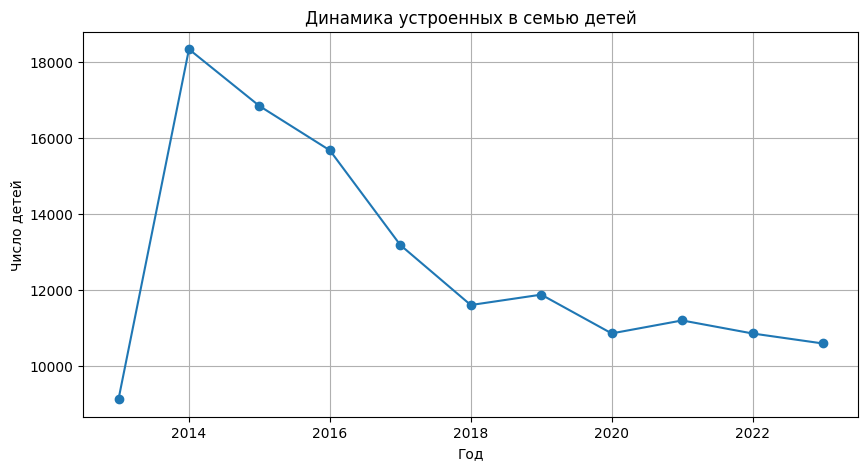

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
"""Горизонт - год, вертикаль - число сирот"""
plt.plot(df_fam_children_by_year['year'], df_fam_children_by_year['indicator_value'], marker='o', linestyle='-')
plt.title('Динамика устроенных в семью детей')
plt.xlabel('Год')
plt.ylabel('Число детей')
plt.grid(True)
plt.show()

>Вывод:
В целом рост резко отрицательный с 2014 по 2018 почти стабильно (максимум был вначале - 18000+, стал минимум - 12000-), потом на [2018, 2023] с небольшими отклонениями вверх-вниз стабильный очень медленный спад между 12000 и 11000.

>DONE:
- [x] Дети, устроенные в семьи за год

# Отмены решений о передаче в семью (возврат детей, ранее устроенных в семьи, в органы опеки)

Чтобы точнее вывести связи **indicator_categories** с dimension и main_level и не ошибаться в том, какие значения в строках с чем точно соотносятся:

In [9]:
target_list = ['indicator_category', 'dimension', 'main_level', 'indicator']


In [11]:
df_otmen = df['main_level'].str.contains('отмен', na=False, case=False)
df_otmen = df[df_otmen]
print(df_otmen[target_list].drop_duplicates().to_string(max_colwidth=60))

                                                 indicator_category                                                    dimension                                                   main_level                                                    indicator
42542   2. Движение численности детей, находящихся на воспитании...                                Опекаемые (подопечные), всего  отменено решений о передаче ребенка на воспитание в семь...  отменено решений о передаче ребенка на воспитание в семь...
42543   2. Движение численности детей, находящихся на воспитании...                                Опекаемые (подопечные), всего  отменено решений о передаче ребенка на воспитание в семь...  отменено решений о передаче ребенка на воспитание в семь...
42544   2. Движение численности детей, находящихся на воспитании...                                Опекаемые (подопечные), всего  отменено решений о передаче ребенка на воспитание в семь...  отменено решений о передаче ребенка на воспитание в семь

In [12]:
print(df['indicator_category'].unique())

<StringArray>
[                      '1. Учет и устройство детей, оставшихся без попечения родителей',
 '2. Движение численности детей, находящихся на воспитании в семьях, за предыдущий год',
                                                          '3. Устройство детей в семьи',
                           '4. Граждан, желающих принять ребенка на воспитание в семьи',
                                                                 '5. Зашита прав детей',
                                                     '6. Специалисты по охране детства']
Length: 6, dtype: str


In [29]:
df_test = df[df['main_level'] == 'отменено решений о передаче ребенка на воспитание в семью, всего']
print("Строк с таким main_level:", len(df_test))
if len(df_test) > 0:
    print("Категории:", df_test['indicator_category'].unique())
    print("Dimension:", df_test['dimension'].unique())
    print(df_test[['year', 'region', 'indicator_value']].head())

Строк с таким main_level: 16524
Категории: <StringArray>
['2. Движение численности детей, находящихся на воспитании в семьях, за предыдущий год']
Length: 1, dtype: str
Dimension: <StringArray>
[                                                                                                                                    'Опекаемые (подопечные), всего',
                                                                                                                    'Опекаемые (подопечные) посторонними гражданами',
                                                'Опекаемые (подопечные) добровольно переданные родителями по заявлению о назначении их ребенку опекуна (попечителя)',
                                                                                                'Опекаемые (подопечные), на которых выплачиваются денежные средства',
                                                                                     'Опекаемые (подопечные), переданные под предварительную оп

In [30]:
df_t2 = df[df['main_level'] == 'отменено решений о передаче ребенка на воспитание в семью, всего']
print(df_t2['dimension'].unique())

<StringArray>
[                                                                                                                                    'Опекаемые (подопечные), всего',
                                                                                                                    'Опекаемые (подопечные) посторонними гражданами',
                                                'Опекаемые (подопечные) добровольно переданные родителями по заявлению о назначении их ребенку опекуна (попечителя)',
                                                                                                'Опекаемые (подопечные), на которых выплачиваются денежные средства',
                                                                                     'Опекаемые (подопечные), переданные под предварительную опеку (попечительство)',
                                                                                  'Опекаемые (подопечные), переданные на безвозмездную форму опеки (попечите

In [ ]:
df_cancel_all = df[df['main_level'] == 'отменено решений о передаче ребенка на воспитание в семью, всего']
print("Уникальные dimension:")
print(df_cancel_all['dimension'].unique())

Уникальные dimension:
<StringArray>
[                                                                                                                                    'Опекаемые (подопечные), всего',
                                                                                                                    'Опекаемые (подопечные) посторонними гражданами',
                                                'Опекаемые (подопечные) добровольно переданные родителями по заявлению о назначении их ребенку опекуна (попечителя)',
                                                                                                'Опекаемые (подопечные), на которых выплачиваются денежные средства',
                                                                                     'Опекаемые (подопечные), переданные под предварительную опеку (попечительство)',
                                                                                  'Опекаемые (подопечные), переданные на безвозмездную

In [ ]:
df_canceled_families = df[
    (df['main_level'] == 'отменено решений о передаче ребенка на воспитание в семью, всего') & \
    (df['dimension'] != 'Опекаемые (подопечные), всего')
]

In [23]:
cancs_by_year = df_canceled_families.groupby('year')['indicator_value'].sum().reset_index()

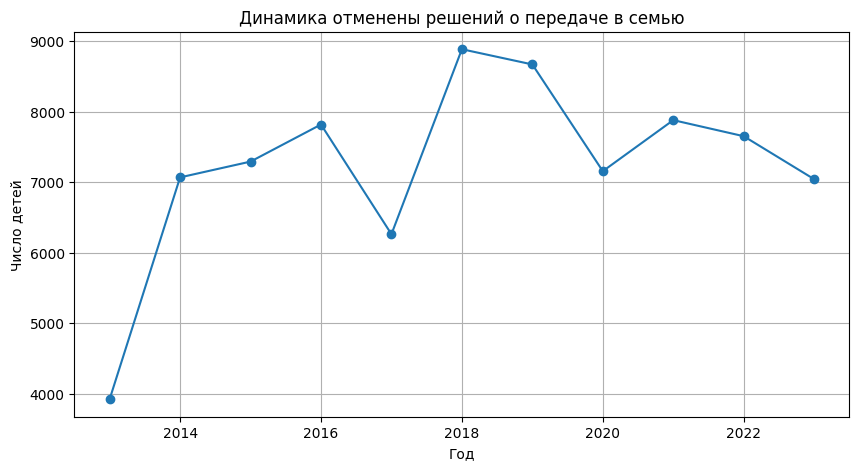

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
"""Горизонт - год, вертикаль - число сирот"""
plt.plot(cancs_by_year['year'], cancs_by_year['indicator_value'], marker='o', linestyle='-')
plt.title('Динамика отменены решений о передаче в семью')
plt.xlabel('Год')
plt.ylabel('Число детей')
plt.grid(True)
plt.show()

>DONE:
- [x] Отмены решений о передаче в семью (возврат детей, ранее устроенных в семьи, в органы опеки)